In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Read training dataset
df = pd.read_csv('../datasets/pixlabel.csv')
df.head(3)

,RECORD,FILENAME,LABEL,COL,ROW,TOTALCOLS,TOTALROWS,TIMESTAMP,R1,G1,B1
0,1,example.jpg,canopy,858,208,917,687,2024-03-29T04:59:28.723Z,237,2,2
1,2,example.jpg,canopy,874,223,917,687,2024-03-29T04:59:36.440Z,110,159,129
2,3,example.jpg,canopy,777,213,917,687,2024-03-29T04:59:41.010Z,135,184,145


In [10]:
df['cats'], uniques = df['LABEL'].factorize()
df.head(3)


,RECORD,FILENAME,LABEL,COL,ROW,TOTALCOLS,TOTALROWS,TIMESTAMP,R1,G1,B1,cats
0,1,example.jpg,canopy,858,208,917,687,2024-03-29T04:59:28.723Z,237,2,2,0
1,2,example.jpg,canopy,874,223,917,687,2024-03-29T04:59:36.440Z,110,159,129,0
2,3,example.jpg,canopy,777,213,917,687,2024-03-29T04:59:41.010Z,135,184,145,0


In [11]:
idx_canopy = df['LABEL'] == 'canopy'
idx_background = df['LABEL'] == 'background'

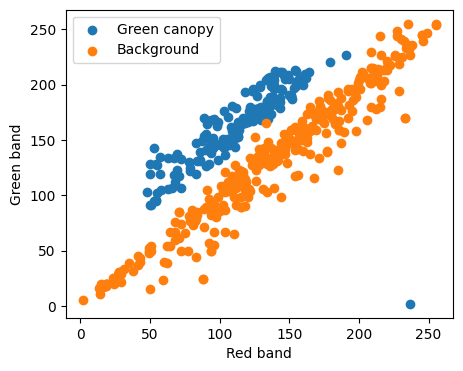

In [48]:
plt.figure(figsize=(5,4))
plt.scatter(df.loc[idx_canopy, 'R1'], df.loc[idx_canopy, 'G1'], label='Green canopy')
plt.scatter(df.loc[idx_background, 'R1'], df.loc[idx_background, 'G1'], label='Background')
plt.xlabel('Red band')
plt.ylabel('Green band')
plt.legend()
plt.show()

In [18]:
# Read image
RGB = plt.imread('../datasets/images/grassland.jpg')
R = RGB[:,:,0]
G = RGB[:,:,1]
B = RGB[:,:,2]

In [35]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(df[['R1','G1','B1']].values/255, df['cats'])

In [36]:
clf.score(df[['R1','G1','B1']].values/255, df['cats'])

1.0

In [37]:
X = np.column_stack( (R.flatten(), G.flatten(), B.flatten()) )
X.shape

(262144, 3)

In [38]:
bw = clf.predict(X)

In [39]:
bw = np.reshape(bw, R.shape)

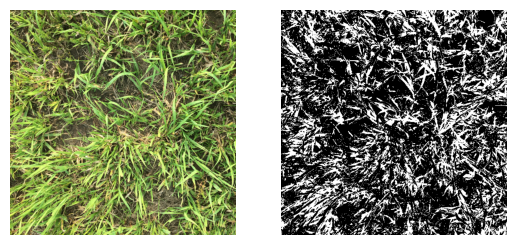

In [44]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(RGB)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(bw, cmap='binary')
plt.axis('off')

plt.show()